<a href="https://colab.research.google.com/github/isil-ada/stellar-mlp-classification/blob/main/5_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5 — PyTorch MLP
## Stellar Classification — En İyi Modellerle PyTorch Uygulaması

Bu notebook, 3. notebook'ta NumPy ile sıfırdan yazılan MLP modellerini
**PyTorch** kullanarak aynı mimariler ile tekrar uygular.

**Kullanılan mimariler** (3. notebook'taki en iyi modellerden seçildi):
| Model | Mimari | Özellik |
|-------|--------|---------|
| M1 | 14→32→3 | Temel model (1 gizli katman) |
| M4 | 14→64→32→3 | 2 gizli katman |
| M5 | 14→64→32→3 | 2 gizli katman + L2 (weight_decay=0.01) |
| M6 | 14→64→32→16→3 | 3 gizli katman |

**Optimizer:** PyTorch varsayılanı için `Adam` kullanılır

**Aktivasyon:** `tanh`

**Loss:** `CrossEntropyLoss` (içinde softmax var)


# **1. Kütüphaneler ve Veri Hazırlama**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cpu


In [2]:
# Veri yükleme
df = pd.read_csv("/content/star_classification.csv.zip")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


In [5]:
print("\nEksik değer:")
print(df.isnull().sum())


Eksik değer:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [6]:
print("Sınıf dağılımı:")
print(df['class'].value_counts())

Sınıf dağılımı:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


In [7]:
# ID sütunlarını sil
drop_cols = ['obj_ID','run_ID','rerun_ID','cam_col','field_ID',
             'spec_obj_ID','plate','MJD','fiber_ID']
df_clean = df.drop(columns=drop_cols).copy()

In [8]:
# Özellik mühendisliği: astronomik renk indeksleri
for a, b in [('u','g'),('g','r'),('r','i'),('i','z'),('u','r')]:
    df_clean[f'{a}_{b}'] = df_clean[a] - df_clean[b]
df_clean['redshift_sq'] = df_clean['redshift'] ** 2

In [9]:
# Label encoding: GALAXY=0, QSO=1, STAR=2
le = LabelEncoder()
y_raw = le.fit_transform(df_clean['class'])

In [10]:
# Özellik matrisi
feature_cols = ['alpha','delta','u','g','r','i','z','redshift',
                'u_g','g_r','r_i','i_z','u_r','redshift_sq']
X_raw = df_clean[feature_cols].values

In [11]:
# StandardScaler (tek fit: train üzerinde)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [12]:
# train test val split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_raw, test_size=0.30, random_state=42, stratify=y_raw)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

In [13]:
# NumPy → PyTorch Tensor
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32).to(device),
            torch.tensor(y, dtype=torch.long).to(device))

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t,   y_val_t   = to_tensor(X_val,   y_val)
X_test_t,  y_test_t  = to_tensor(X_test,  y_test)

In [14]:
print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print('Sınıflar:', le.classes_)

Train: 70000  Val: 10000  Test: 20000
Sınıflar: ['GALAXY' 'QSO' 'STAR']


# **2. Model Sınıfı**

`layers` listesiyle herhangi bir derinlikte MLP oluşturulabilir.
Gizli katmanlar `tanh`, çıkış katmanı ham logit döndürür
(`CrossEntropyLoss` içinde softmax hesaplanır).
He initialization uygulanır.


In [15]:
class MLP(nn.Module):
    """
    Genel N-katmanlı MLP.
    layers: örn. [14, 64, 32, 3]
    Gizli katmanlar → tanh | Çıkış → ham logit (CrossEntropyLoss softmax içerir)

    Constructor : __init__(layers)
    Public      : forward(x), predict(x)
    Private     : _build_network(), _init_weights()
    """

    def __init__(self, layers):
        """Constructor: ağ katmanlarını ve ağırlıkları başlatır."""
        super().__init__()
        self.layers = layers
        self.net    = self._build_network()
        self._init_weights()

    # ── Private metotlar ─────────────────────────────────────────────────
    def _build_network(self):
        """Katman listesinden Sequential ağı oluşturur. (private)"""
        net = nn.Sequential()
        for i in range(len(self.layers) - 1):
            net.add_module(f'linear_{i}', nn.Linear(self.layers[i], self.layers[i+1]))
            if i < len(self.layers) - 2:
                net.add_module(f'tanh_{i}', nn.Tanh())
        return net

    def _init_weights(self):
        """He initialization uygular — NumPy notebook ile aynı. (private)"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='tanh')
                nn.init.zeros_(m.bias)

    # ── Public metotlar ──────────────────────────────────────────────────
    def forward(self, x):
        """İleri yayılım: ham logit döndürür. (public)"""
        return self.net(x)

    def predict(self, x):
        """En yüksek olasılıklı sınıfı döndürür. (public)"""
        self.eval()
        with torch.no_grad():
            return self.forward(x).argmax(dim=1)


# Test
test_model = MLP([14, 64, 32, 3]).to(device)
print(test_model)
print('Parametre sayısı:', sum(p.numel() for p in test_model.parameters()))

MLP(
  (net): Sequential(
    (linear_0): Linear(in_features=14, out_features=64, bias=True)
    (tanh_0): Tanh()
    (linear_1): Linear(in_features=64, out_features=32, bias=True)
    (tanh_1): Tanh()
    (linear_2): Linear(in_features=32, out_features=3, bias=True)
  )
)
Parametre sayısı: 3139


# **3. Eğitim Fonksiyonu**


In [16]:
def train_pytorch(layers, n_epochs=300, lr=1e-3, weight_decay=0.0, print_every=50):
    """
    layers       : mimari listesi, örn. [14, 64, 32, 3]
    n_epochs     : iterasyon sayısı
    lr           : learning rate (Adam varsayılanı: 1e-3)
    weight_decay : L2 regularizasyon katsayısı
    """
    torch.manual_seed(42)
    model     = MLP(layers).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_accs, val_accs, train_losses = [], [], []

    for epoch in range(n_epochs):
        model.train()
        logits = model(X_train_t)
        loss   = criterion(logits, y_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                ta = accuracy_score(y_train, model.predict(X_train_t).cpu().numpy())
                va = accuracy_score(y_val,   model.predict(X_val_t).cpu().numpy())
            train_accs.append(ta)
            val_accs.append(va)
            train_losses.append(loss.item())

            if epoch % print_every == 0:
                print(f'epoch {epoch:3d} | loss={loss.item():.4f} | '
                      f'train_acc={ta:.4f} | val_acc={va:.4f}')

    model.eval()
    with torch.no_grad():
        test_pred = model.predict(X_test_t).cpu().numpy()
    test_acc = accuracy_score(y_test, test_pred)

    return model, train_losses, train_accs, val_accs, test_acc, test_pred

# **4. Model Eğitimi**


In [17]:
pytorch_configs = [
    {'name': 'M1: 1 gizli n_h=32',    'layers': [14, 32, 3],         'wd': 0.0},
    {'name': 'M4: 2 gizli 64-32',      'layers': [14, 64, 32, 3],     'wd': 0.0},
    {'name': 'M5: 2 gizli +L2',        'layers': [14, 64, 32, 3],     'wd': 0.01},
    {'name': 'M6: 3 gizli 64-32-16',   'layers': [14, 64, 32, 16, 3], 'wd': 0.0},
]

pt_results = []

for cfg in pytorch_configs:
    print(f"\n>>> {cfg['name']}")
    model, tl, ta, va, test_acc, test_pred = train_pytorch(
        cfg['layers'],
        n_epochs=300,
        lr=1e-3,               # Adam varsayılanı
        weight_decay=cfg['wd']
    )
    gap = ta[-1] - va[-1]
    pt_results.append({
        'name': cfg['name'], 'model': model,
        'tl': tl, 'ta': ta, 'va': va,
        'test_acc': test_acc, 'gap': gap,
        'test_pred': test_pred
    })
    print(f'  Test Acc={test_acc:.4f}  Gap={gap:.4f}')


>>> M1: 1 gizli n_h=32
epoch   0 | loss=1.1177 | train_acc=0.4355 | val_acc=0.4386
epoch  50 | loss=0.7066 | train_acc=0.7981 | val_acc=0.8002
epoch 100 | loss=0.5648 | train_acc=0.8311 | val_acc=0.8345
epoch 150 | loss=0.4946 | train_acc=0.8416 | val_acc=0.8426
epoch 200 | loss=0.4436 | train_acc=0.8499 | val_acc=0.8489
epoch 250 | loss=0.3999 | train_acc=0.8565 | val_acc=0.8575
  Test Acc=0.8649  Gap=0.0004

>>> M4: 2 gizli 64-32
epoch   0 | loss=1.3731 | train_acc=0.3958 | val_acc=0.3976
epoch  50 | loss=0.4760 | train_acc=0.8393 | val_acc=0.8405
epoch 100 | loss=0.3469 | train_acc=0.8752 | val_acc=0.8723
epoch 150 | loss=0.2737 | train_acc=0.9136 | val_acc=0.9109
epoch 200 | loss=0.2322 | train_acc=0.9283 | val_acc=0.9279
epoch 250 | loss=0.2064 | train_acc=0.9384 | val_acc=0.9378
  Test Acc=0.9464  Gap=0.0015

>>> M5: 2 gizli +L2
epoch   0 | loss=1.3731 | train_acc=0.3956 | val_acc=0.3974
epoch  50 | loss=0.4856 | train_acc=0.8385 | val_acc=0.8401
epoch 100 | loss=0.3681 | train_

# **5. Sonuçlar**


In [18]:
# Özet tablo
print(f"{'Model':<25} {'Train':>7} {'Val':>7} {'Test':>7} {'Gap':>8}  Durum")
print('-' * 72)
for r in pt_results:
    durum = 'Overfitting' if r['gap'] > 0.05 else ('Underfitting' if r['ta'][-1] < 0.88 else 'Iyi fit')
    print(f"{r['name']:<25} {r['ta'][-1]:>7.4f} {r['va'][-1]:>7.4f} {r['test_acc']:>7.4f} {r['gap']:>8.4f}  {durum}")

best_pt = max(pt_results, key=lambda x: x['test_acc'])
print(f"\nEn iyi model: {best_pt['name']} | Test Acc={best_pt['test_acc']:.4f}")

Model                       Train     Val    Test      Gap  Durum
------------------------------------------------------------------------
M1: 1 gizli n_h=32         0.8636  0.8632  0.8649   0.0004  Underfitting
M4: 2 gizli 64-32          0.9438  0.9423  0.9464   0.0015  Iyi fit
M5: 2 gizli +L2            0.9320  0.9315  0.9348   0.0005  Iyi fit
M6: 3 gizli 64-32-16       0.9540  0.9530  0.9549   0.0010  Iyi fit

En iyi model: M6: 3 gizli 64-32-16 | Test Acc=0.9549


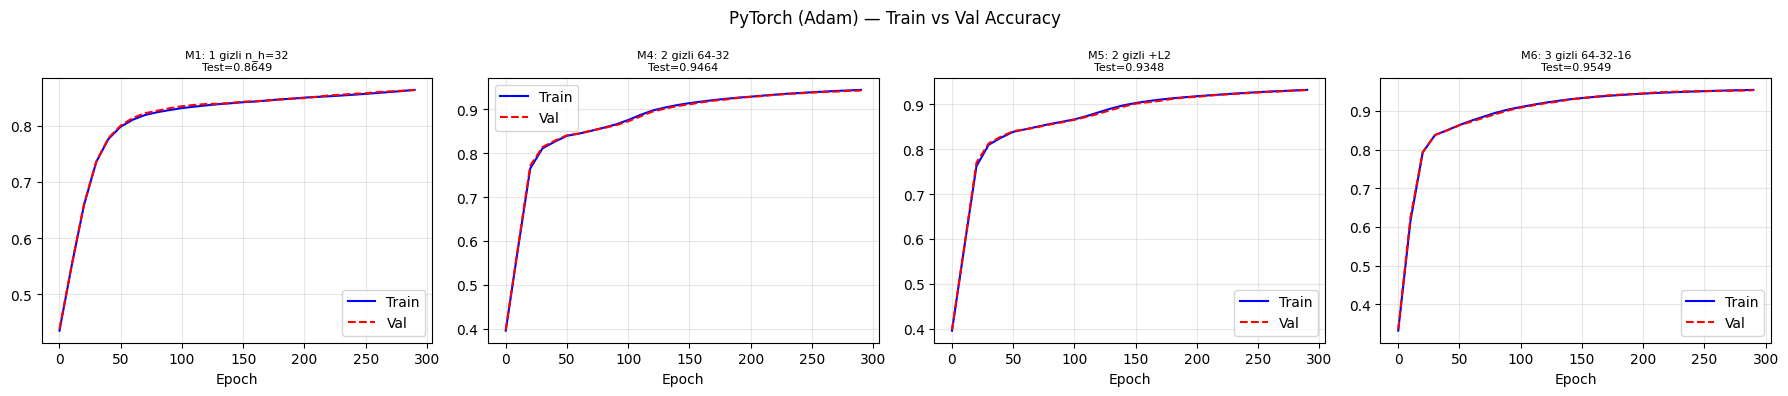

In [19]:
# Train vs Val Accuracy grafikleri
fig, axes = plt.subplots(1, len(pt_results), figsize=(18, 4))

for ax, r in zip(axes, pt_results):
    s = list(range(0, len(r['ta']) * 10, 10))
    ax.plot(s, r['ta'], 'b-',  label='Train')
    ax.plot(s, r['va'], 'r--', label='Val')
    ax.set_title(f"{r['name']}\nTest={r['test_acc']:.4f}", fontsize=8)
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('PyTorch (Adam) — Train vs Val Accuracy', fontsize=12)
plt.tight_layout(); plt.show()

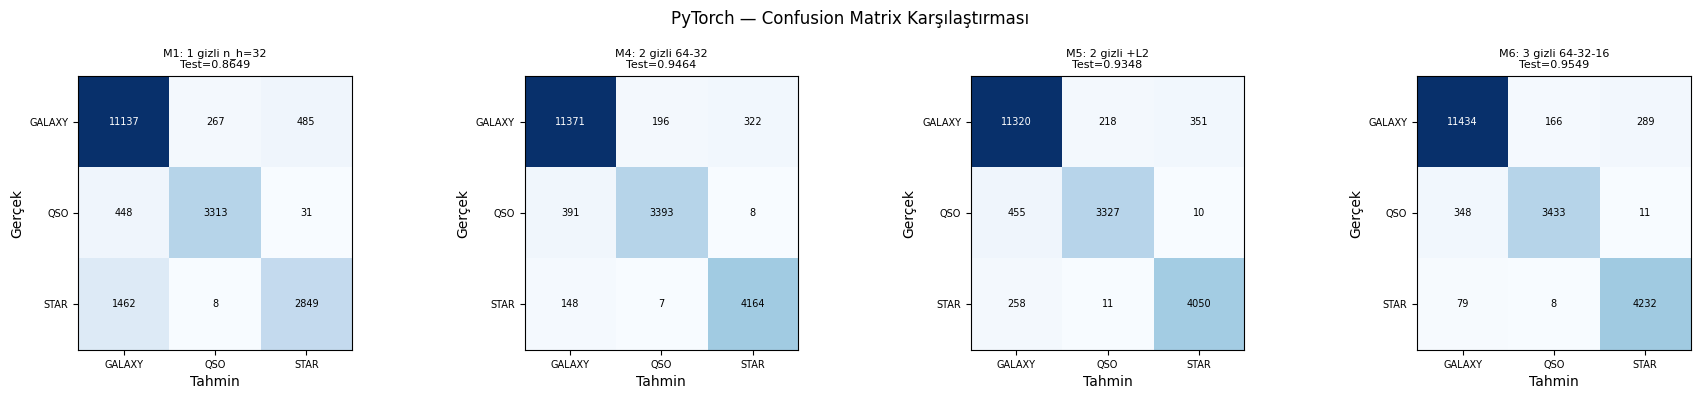

In [20]:
# Confusion Matrix — tüm modeller
fig, axes = plt.subplots(1, len(pt_results), figsize=(18, 4))

for ax, r in zip(axes, pt_results):
    cm = confusion_matrix(y_test, r['test_pred'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(le.classes_, fontsize=7)
    ax.set_yticklabels(le.classes_, fontsize=7)
    ax.set_title(f"{r['name']}\nTest={r['test_acc']:.4f}", fontsize=8)
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=7,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.suptitle('PyTorch — Confusion Matrix Karşılaştırması', fontsize=12)
plt.tight_layout(); plt.show()

In [21]:
# En iyi modelin detaylı metrikleri
print(f"Classification Report — {best_pt['name']}:")
print(classification_report(y_test, best_pt['test_pred'], target_names=le.classes_))

Classification Report — M6: 3 gizli 64-32-16:
              precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96     11889
         QSO       0.95      0.91      0.93      3792
        STAR       0.93      0.98      0.96      4319

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.95      0.95     20000

